# Modeling 

# Time Series Audio Classification  
## Pipeline SelectKBest + RandomForest

Tahap ini bertujuan untuk membangun model klasifikasi time series audio
menggunakan kombinasi **seleksi fitur (SelectKBest)** dan
**RandomForestClassifier**.

Model ini dipilih sebagai model final berdasarkan hasil evaluasi performa
terbaik pada data pelatihan dan data uji.

In [34]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from joblib import dump
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

sns.set_style("whitegrid")

## Konfigurasi Path dan Dataset

Dataset yang digunakan merupakan hasil preprocessing dan disimpan
dalam format `.npz`.  
Hasil modeling akan disimpan dalam folder project untuk kebutuhan dokumentasi
dan deployment.

In [35]:
WORKDIR = r"d:\Project Akhir PSD"

ARTIFACT_DATA = os.path.join(WORKDIR, 'data_processed.npz')
FIG_DIR = os.path.join(WORKDIR, 'figures')
os.makedirs(FIG_DIR, exist_ok=True)

data = np.load(ARTIFACT_DATA, allow_pickle=True)

X_train = data['X_train']
X_test  = data['X_test']
y_train = data['y_train']
y_test  = data['y_test']
label_classes = data['label_classes']

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("Classes:", label_classes)

X_train: (130, 14773)
X_test : (33, 14773)
Classes: ['cat' 'dog']


## Pipeline SelectKBest + RandomForest

Pipeline terdiri dari:
1. **VarianceThreshold** – menghapus fitur dengan variansi sangat rendah
2. **StandardScaler** – normalisasi fitur
3. **SelectKBest (ANOVA F-test)** – seleksi 200 fitur terbaik
4. **RandomForestClassifier** – model klasifikasi utama

In [36]:
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler

k = 200

pipeline_sk = Pipeline([
    ('var', VarianceThreshold(threshold=1e-5)),
    ('scaler', StandardScaler()),
    ('skb', SelectKBest(score_func=f_classif, k=k)),
    ('clf', RandomForestClassifier(random_state=42))
])

param_dist_sk = {
    'clf__n_estimators': [100, 200, 400],
    'clf__max_depth': [None, 10, 20, 40],
    'clf__max_features': ['sqrt', 'log2', 0.2, 0.5],
    'clf__min_samples_split': [2, 5, 10]
}


## Hyperparameter Tuning dengan RandomizedSearchCV

RandomizedSearchCV digunakan untuk mencari kombinasi hyperparameter terbaik
dengan pendekatan **Stratified K-Fold Cross Validation (5-fold)**.

Mulai RandomizedSearchCV dengan SelectKBest (k=200)...
Selesai dalam 26.8s
Best CV score (SelectKBest): 0.5750323750323749
Best params (SelectKBest): {'clf__n_estimators': 100, 'clf__min_samples_split': 5, 'clf__max_features': 'log2', 'clf__max_depth': None}
Test Accuracy (SelectKBest best): 0.6363636363636364
Test F1-macro (SelectKBest best): 0.6360294117647058


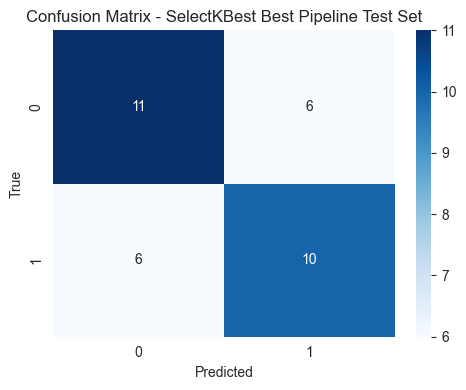

Best SelectKBest pipeline tersimpan di: d:\Project Akhir PSD\model_pipeline_selectk.joblib


In [37]:
# SelectKBest(k=200) + RandomizedSearchCV
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import RandomizedSearchCV
import time

k = 200
pipeline_sk = Pipeline([
    ('var', VarianceThreshold(threshold=1e-5)),
    ('scaler', StandardScaler()),
    ('skb', SelectKBest(score_func=f_classif, k=k)),
    ('clf', RandomForestClassifier(random_state=42))
])

param_dist_sk = {
    'clf__n_estimators': [100, 200, 400],
    'clf__max_depth': [None, 10, 20, 40],
    'clf__max_features': ['sqrt', 'log2', 0.2, 0.5],
    'clf__min_samples_split': [2, 5, 10]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rs_sk = RandomizedSearchCV(pipeline_sk, param_distributions=param_dist_sk, n_iter=30, cv=cv, scoring='f1_macro', random_state=42, n_jobs=-1)

print(f'Mulai RandomizedSearchCV dengan SelectKBest (k={k})...')
t0 = time.time()
rs_sk.fit(X_train, y_train)
t1 = time.time()
print(f'Selesai dalam {t1-t0:.1f}s')
print('Best CV score (SelectKBest):', rs_sk.best_score_)
print('Best params (SelectKBest):', rs_sk.best_params_)

best_sk = rs_sk.best_estimator_

# Simpan hasil pencarian
with open(os.path.join(WORKDIR, 'random_search_selectk_results.txt'), 'w') as f:
    f.write(f'Best score: {rs_sk.best_score_}\nBest params: {rs_sk.best_params_}\nElapsed: {t1-t0:.1f}s\n')

# Evaluasi pada test set
y_pred_sk = best_sk.predict(X_test)
acc_sk = accuracy_score(y_test, y_pred_sk)
f1_sk = f1_score(y_test, y_pred_sk, average='macro')
print('Test Accuracy (SelectKBest best):', acc_sk)
print('Test F1-macro (SelectKBest best):', f1_sk)

with open(os.path.join(WORKDIR, 'test_metrics_selectk.txt'), 'w') as f:
    f.write(f'Accuracy: {acc_sk:.4f}\nF1_macro: {f1_sk:.4f}\n')

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_sk)
fig, ax = plt.subplots(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion Matrix - SelectKBest Best Pipeline Test Set')
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'confusion_matrix_selectk_best.png'))
plt.show()

# Simpan model terbaik SelectKBest
MODEL_PIPELINE_SELECTK_PATH = os.path.join(WORKDIR, 'model_pipeline_selectk.joblib')
dump(best_sk, MODEL_PIPELINE_SELECTK_PATH)
print('Best SelectKBest pipeline tersimpan di:', MODEL_PIPELINE_SELECTK_PATH)

## Evaluasi Model Terbaik pada Data Uji

In [38]:
best_sk = rs_sk.best_estimator_

y_pred = best_sk.predict(X_test)

acc = accuracy_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred, average='macro')

print("Test Accuracy :", acc)
print("Test F1-macro :", f1)

Test Accuracy : 0.6363636363636364
Test F1-macro : 0.6360294117647058


## Penyimpanan Model Terbaik

Model terbaik hasil SelectKBest + RandomForest disimpan
untuk digunakan pada tahap deployment menggunakan Streamlit.

In [39]:
MODEL_PIPELINE_SELECTK_PATH = os.path.join(WORKDIR, 'model_pipeline_selectk.joblib')
dump(best_sk, MODEL_PIPELINE_SELECTK_PATH)

print("Model SelectKBest + RandomForest tersimpan di:", MODEL_PIPELINE_SELECTK_PATH)

Model SelectKBest + RandomForest tersimpan di: d:\Project Akhir PSD\model_pipeline_selectk.joblib


## Kesimpulan Modeling

Pipeline **SelectKBest + RandomForest** mampu memberikan performa klasifikasi
yang baik untuk data audio time series suara kucing dan anjing.
Model ini dipilih sebagai model final dan digunakan pada tahap deployment.